# 02_feature_check

This notebook validates the engineered feature set for the stock prediction project.

It checks:
- processed feature file loads successfully
- schema and feature columns look correct
- missing values and duplicates are absent
- target balance is reasonable
- feature distributions look sane
- rolling features behave as expected for one ticker
- basic correlations can be inspected before modeling


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)


In [2]:
# This should work if the notebook is placed inside the project's notebooks/ folder.
PROJECT_ROOT = Path.cwd().resolve().parents[0] if Path.cwd().name == 'notebooks' else Path.cwd()
features_path = PROJECT_ROOT / 'data' / 'processed' / 'model_features.parquet'

print('Project root:', PROJECT_ROOT)
print('Features file exists:', features_path.exists())
print('Features path:', features_path)


Project root: C:\Users\dremo\Desktop\Stocker
Features file exists: True
Features path: C:\Users\dremo\Desktop\Stocker\data\processed\model_features.parquet


In [3]:
df = pd.read_parquet(features_path)
df.head()

,date,ticker,open,high,low,close,adjusted_close,volume,return_1d,return_5d,return_20d,sma_5,sma_20,sma_50,dist_from_sma_20,dist_from_sma_50,volatility_5d,volatility_20d,volume_avg_20d,volume_ratio_20d,target_next_day_up
0,2006-07-24,AAPL,2.18786,2.21786,2.15821,2.19357,2.19357,722856400,0.011528,0.172806,0.044025,2.068856,2.005964,2.113164,0.093524,0.038050,0.048033,0.036409,857689840.0,0.842795,1
1,2006-07-25,AAPL,2.20643,2.21750,2.17071,2.21179,2.21179,589069600,0.008306,0.170699,0.049839,2.133356,2.011214,2.109043,0.099729,0.048717,0.048258,0.036430,863816520.0,0.681938,1
2,2006-07-26,AAPL,2.21429,2.30857,2.20286,2.28107,2.28107,898427600,0.031323,0.180593,0.112136,2.203142,2.022714,2.106243,0.127727,0.083004,0.047955,0.036258,881207320.0,1.019542,0
3,2006-07-27,AAPL,2.30357,2.32214,2.24500,2.26429,2.26429,735044800,-0.007356,0.047938,0.131741,2.223858,2.035893,2.105114,0.112185,0.075614,0.014145,0.035697,875424340.0,0.839644,1
4,2006-07-28,AAPL,2.28357,2.34571,2.26786,2.34250,2.34250,691507600,0.034541,0.080205,0.112261,2.258644,2.047715,2.105350,0.143958,0.112642,0.017340,0.034687,866329800.0,0.798204,1


In [4]:
df.tail()

,date,ticker,open,high,low,close,adjusted_close,volume,return_1d,return_5d,return_20d,sma_5,sma_20,sma_50,dist_from_sma_20,dist_from_sma_50,volatility_5d,volatility_20d,volume_avg_20d,volume_ratio_20d,target_next_day_up
24750,2026-03-23,SPY,658.070007,662.620000,653.94000,655.380000,655.380000,134802700,0.010500,-0.020403,-0.039581,659.193994,674.322500,683.208197,-0.028091,-0.040732,0.011458,0.008840,94185380.0,1.431249,0
24751,2026-03-24,SPY,651.320010,657.030029,649.88000,653.179990,653.179990,96457500,-0.003357,-0.026253,-0.049713,655.671996,672.614001,682.390397,-0.028893,-0.042806,0.010882,0.008571,95318320.0,1.011951,1
24752,2026-03-25,SPY,658.669980,660.890010,654.23999,656.820010,656.820010,90653800,0.005573,-0.006970,-0.052413,654.750000,670.797500,681.623597,-0.020837,-0.036389,0.010478,0.008400,97032535.0,0.934262,0
24753,2026-03-26,SPY,652.059998,654.849980,644.82001,645.090027,645.090027,96494400,-0.017859,-0.022295,-0.064137,651.808007,668.587002,680.649997,-0.035144,-0.052244,0.012874,0.009049,98273705.0,0.981894,0
24754,2026-03-27,SPY,642.500000,642.659970,633.10999,634.090027,634.090027,102725900,-0.017052,-0.022326,-0.075657,648.912011,665.992004,679.524598,-0.047901,-0.066862,0.012882,0.009559,99244555.0,1.035078,0


## Shape, schema, and columns

In [5]:
print('Shape:', df.shape)
print('\nDtypes:')
print(df.dtypes)
print('\nColumns:')
print(df.columns.tolist())

Shape: (24755, 21)

Dtypes:
date                  datetime64[ns]
ticker                        object
open                         float64
high                         float64
low                          float64
close                        float64
adjusted_close               float64
volume                         int64
return_1d                    float64
return_5d                    float64
return_20d                   float64
sma_5                        float64
sma_20                       float64
sma_50                       float64
dist_from_sma_20             float64
dist_from_sma_50             float64
volatility_5d                float64
volatility_20d               float64
volume_avg_20d               float64
volume_ratio_20d             float64
target_next_day_up             int64
dtype: object

Columns:
['date', 'ticker', 'open', 'high', 'low', 'close', 'adjusted_close', 'volume', 'return_1d', 'return_5d', 'return_20d', 'sma_5', 'sma_20', 'sma_50', 'dist_from_sma_20', 'di

In [6]:
df.describe(include='all')

,date,ticker,open,high,low,close,adjusted_close,volume,return_1d,return_5d,return_20d,sma_5,sma_20,sma_50,dist_from_sma_20,dist_from_sma_50,volatility_5d,volatility_20d,volume_avg_20d,volume_ratio_20d,target_next_day_up
count,24755,24755,24755.000000,24755.000000,24755.000000,24755.000000,24755.000000,2.475500e+04,24755.000000,24755.000000,24755.000000,24755.000000,24755.000000,24755.000000,24755.000000,24755.000000,24755.000000,24755.000000,2.475500e+04,24755.000000,24755.000000
unique,NaN,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,AAPL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,4951,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2016-05-22 23:09:20.032316928,NaN,135.684937,136.715941,134.584346,135.708133,135.708133,2.160709e+08,0.000933,0.004621,0.018557,135.561362,134.988948,133.806665,0.007582,0.019814,0.015681,0.016765,2.166470e+08,1.006569,0.534397
min,2006-07-24 00:00:00,NaN,0.150000,0.159500,0.143750,0.147500,0.147500,5.855900e+06,-0.307266,-0.372407,-0.497384,0.160500,0.178038,0.188380,-0.377668,-0.458435,0.000426,0.002010,1.551530e+07,0.151360,0.000000
25%,2011-06-21 12:00:00,NaN,23.023499,23.257645,22.556000,22.984000,22.984000,4.476205e+07,-0.007169,-0.015083,-0.022550,22.970250,22.958402,22.509382,-0.013543,-0.015956,0.007567,0.009333,4.817351e+07,0.769554,0.000000
50%,2016-05-23 00:00:00,NaN,73.019997,73.700000,72.501000,73.160000,73.160000,9.060150e+07,0.000892,0.005279,0.019050,72.844000,72.574000,70.878100,0.009806,0.021521,0.012168,0.013814,9.410393e+07,0.928704,1.000000
75%,2021-04-23 00:00:00,NaN,202.040001,203.445000,200.284995,202.084999,202.084999,2.800200e+08,0.009264,0.023899,0.055497,202.356001,201.395000,199.846700,0.029380,0.054925,0.019413,0.020618,3.029071e+08,1.148362,1.000000
max,2026-03-27 00:00:00,NaN,697.049988,697.840030,693.940000,695.489990,695.489990,3.692928e+09,0.298067,0.375147,0.657507,694.465978,691.196994,688.480397,0.417772,0.582815,0.145432,0.087022,1.879186e+09,5.391236,1.000000


## Duplicate and null checks

In [7]:
duplicate_count = df.duplicated(['date', 'ticker']).sum()
print('Duplicate (date, ticker) rows:', duplicate_count)

null_counts = df.isnull().sum().sort_values(ascending=False)
print('\nNull counts by column:')
print(null_counts)

Duplicate (date, ticker) rows: 0

Null counts by column:
date                  0
ticker                0
open                  0
high                  0
low                   0
close                 0
adjusted_close        0
volume                0
return_1d             0
return_5d             0
return_20d            0
sma_5                 0
sma_20                0
sma_50                0
dist_from_sma_20      0
dist_from_sma_50      0
volatility_5d         0
volatility_20d        0
volume_avg_20d        0
volume_ratio_20d      0
target_next_day_up    0
dtype: int64


## Coverage checks

In [8]:
print('Tickers:', sorted(df['ticker'].unique()))
print('Ticker count:', df['ticker'].nunique())
print('Overall date range:', df['date'].min().date(), 'to', df['date'].max().date())

Tickers: ['AAPL', 'MSFT', 'NVDA', 'QQQ', 'SPY']
Ticker count: 5
Overall date range: 2006-07-24 to 2026-03-27


In [9]:
coverage = (
    df.groupby('ticker')
      .agg(
          start_date=('date', 'min'),
          end_date=('date', 'max'),
          rows=('date', 'count')
      )
      .sort_index()
)
coverage

,start_date,end_date,rows
ticker,,,
AAPL,2006-07-24,2026-03-27,4951
MSFT,2006-07-24,2026-03-27,4951
NVDA,2006-07-24,2026-03-27,4951
QQQ,2006-07-24,2026-03-27,4951
SPY,2006-07-25,2026-03-27,4951


## Target balance

In [10]:
target_counts = df['target_next_day_up'].value_counts(dropna=False).sort_index()
target_counts

target_next_day_up
0    11526
1    13229
Name: count, dtype: int64

In [11]:
target_share = df['target_next_day_up'].value_counts(normalize=True).sort_index()
target_share

target_next_day_up
0    0.465603
1    0.534397
Name: proportion, dtype: float64

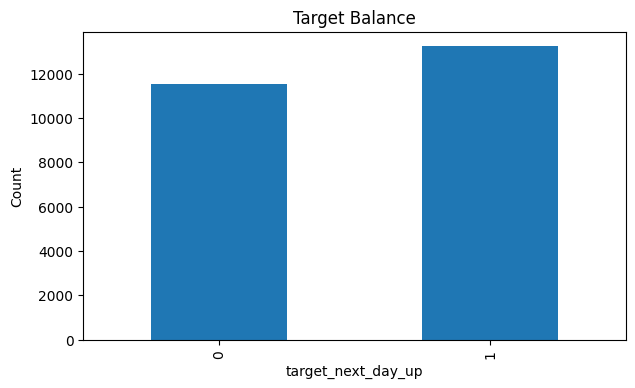

In [12]:
df['target_next_day_up'].value_counts().sort_index().plot(kind='bar', figsize=(7, 4), title='Target Balance')
plt.xlabel('target_next_day_up')
plt.ylabel('Count')
plt.show()

## Basic feature sanity tables

In [13]:
feature_cols = [
    'return_1d', 'return_5d', 'return_20d',
    'sma_5', 'sma_20', 'sma_50',
    'dist_from_sma_20', 'dist_from_sma_50',
    'volatility_5d', 'volatility_20d',
    'volume_avg_20d', 'volume_ratio_20d'
]

df[feature_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
return_1d,24755.0,9.332614e-04,1.998141e-02,-3.072657e-01,-7.169075e-03,8.922596e-04,9.264490e-03,2.980670e-01
return_5d,24755.0,4.620920e-03,4.248106e-02,-3.724066e-01,-1.508276e-02,5.279221e-03,2.389907e-02,3.751473e-01
return_20d,24755.0,1.855723e-02,8.466269e-02,-4.973843e-01,-2.254996e-02,1.905009e-02,5.549722e-02,6.575067e-01
sma_5,24755.0,1.355614e+02,1.516083e+02,1.605000e-01,2.297025e+01,7.284400e+01,2.023560e+02,6.944660e+02
sma_20,24755.0,1.349889e+02,1.510496e+02,1.780375e-01,2.295840e+01,7.257400e+01,2.013950e+02,6.911970e+02
sma_50,24755.0,1.338067e+02,1.498324e+02,1.883800e-01,2.250938e+01,7.087810e+01,1.998467e+02,6.884804e+02
dist_from_sma_20,24755.0,7.581795e-03,4.645343e-02,-3.776680e-01,-1.354329e-02,9.806123e-03,2.937952e-02,4.177723e-01
dist_from_sma_50,24755.0,1.981355e-02,7.699581e-02,-4.584346e-01,-1.595630e-02,2.152073e-02,5.492471e-02,5.828148e-01
volatility_5d,24755.0,1.568149e-02,1.279984e-02,4.257673e-04,7.567460e-03,1.216833e-02,1.941337e-02,1.454324e-01
volatility_20d,24755.0,1.676494e-02,1.105830e-02,2.009868e-03,9.333168e-03,1.381387e-02,2.061764e-02,8.702214e-02


## Feature distributions

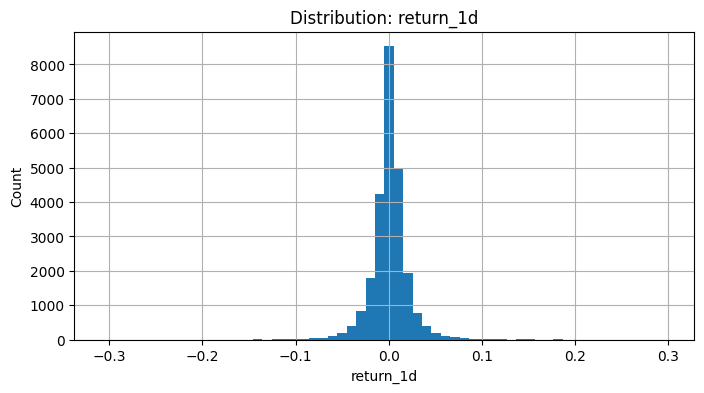

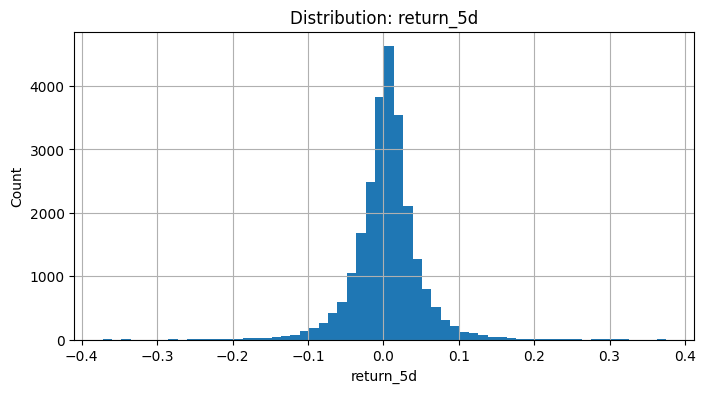

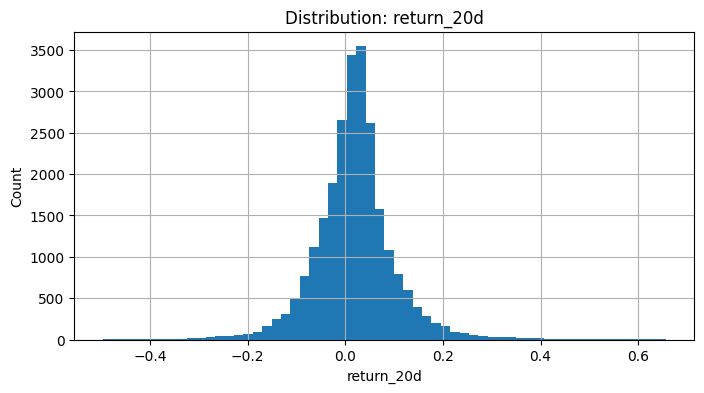

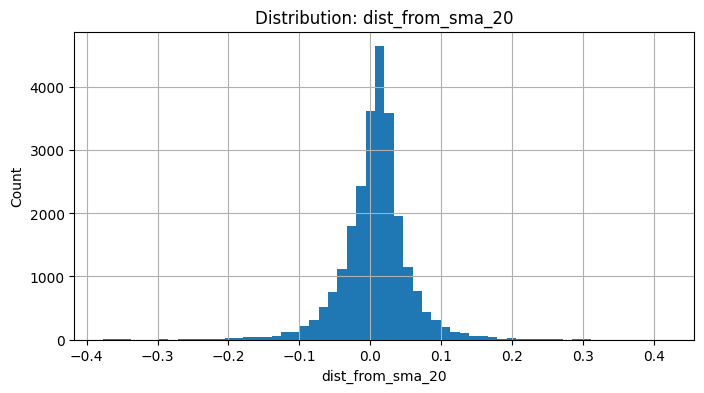

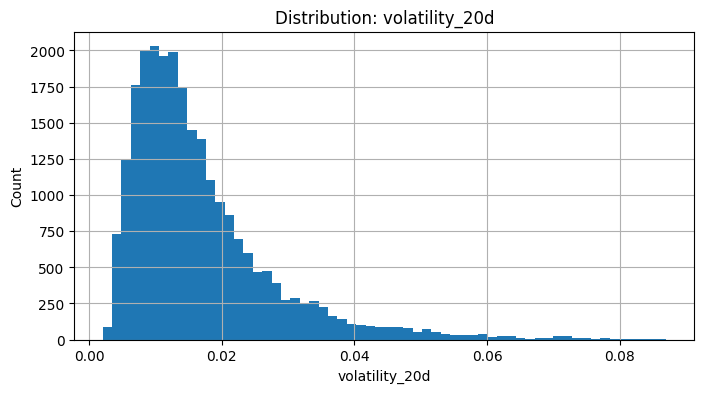

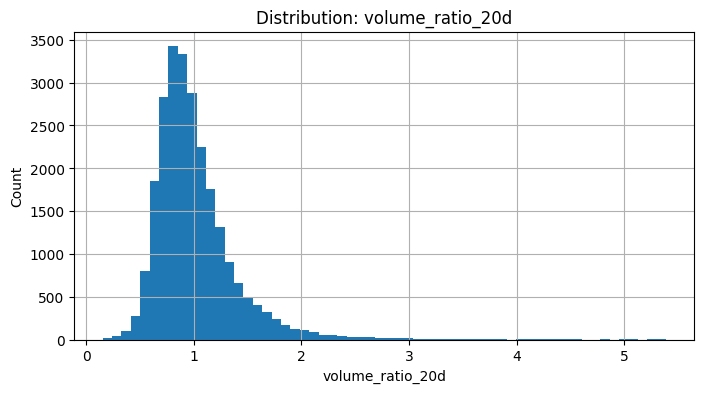

In [14]:
for col in ['return_1d', 'return_5d', 'return_20d', 'dist_from_sma_20', 'volatility_20d', 'volume_ratio_20d']:
    plt.figure(figsize=(8, 4))
    df[col].hist(bins=60)
    plt.title(f'Distribution: {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

## Inspect one ticker in detail

In [15]:
ticker = 'AAPL'
one = df[df['ticker'] == ticker].copy().sort_values('date')
one.head()

,date,ticker,open,high,low,close,adjusted_close,volume,return_1d,return_5d,return_20d,sma_5,sma_20,sma_50,dist_from_sma_20,dist_from_sma_50,volatility_5d,volatility_20d,volume_avg_20d,volume_ratio_20d,target_next_day_up
0,2006-07-24,AAPL,2.18786,2.21786,2.15821,2.19357,2.19357,722856400,0.011528,0.172806,0.044025,2.068856,2.005964,2.113164,0.093524,0.038050,0.048033,0.036409,857689840.0,0.842795,1
1,2006-07-25,AAPL,2.20643,2.21750,2.17071,2.21179,2.21179,589069600,0.008306,0.170699,0.049839,2.133356,2.011214,2.109043,0.099729,0.048717,0.048258,0.036430,863816520.0,0.681938,1
2,2006-07-26,AAPL,2.21429,2.30857,2.20286,2.28107,2.28107,898427600,0.031323,0.180593,0.112136,2.203142,2.022714,2.106243,0.127727,0.083004,0.047955,0.036258,881207320.0,1.019542,0
3,2006-07-27,AAPL,2.30357,2.32214,2.24500,2.26429,2.26429,735044800,-0.007356,0.047938,0.131741,2.223858,2.035893,2.105114,0.112185,0.075614,0.014145,0.035697,875424340.0,0.839644,1
4,2006-07-28,AAPL,2.28357,2.34571,2.26786,2.34250,2.34250,691507600,0.034541,0.080205,0.112261,2.258644,2.047715,2.105350,0.143958,0.112642,0.017340,0.034687,866329800.0,0.798204,1


In [16]:
one[['date', 'close', 'sma_5', 'sma_20', 'sma_50']].tail()

,date,close,sma_5,sma_20,sma_50
4946,2026-03-23,251.49001,250.522006,259.253501,260.9790
4947,2026-03-24,251.64000,250.004006,258.228501,260.8244
4948,2026-03-25,252.62000,250.540006,257.148001,260.6718
4949,2026-03-26,252.89000,251.326004,256.145000,260.5086
4950,2026-03-27,248.80000,251.488002,255.376001,260.2854


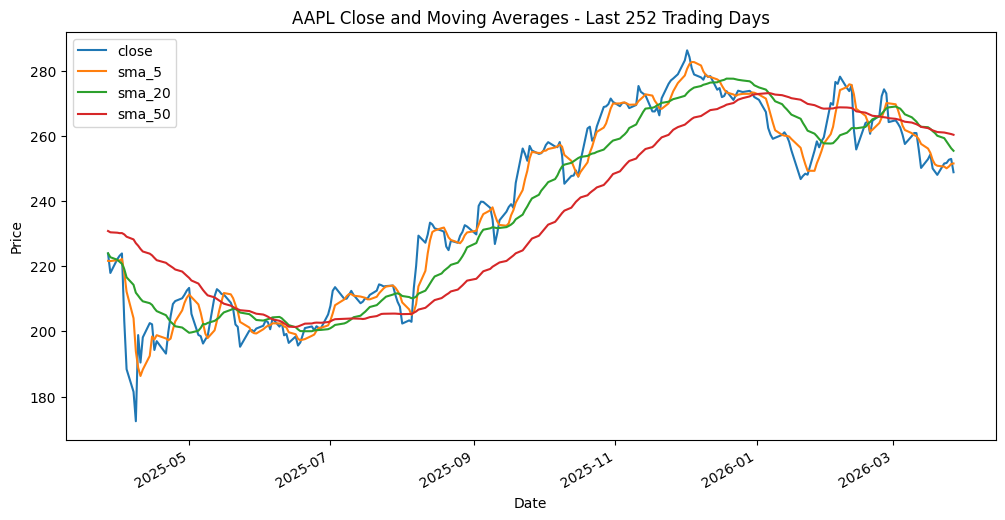

In [17]:
plot_df = one.set_index('date')[['close', 'sma_5', 'sma_20', 'sma_50']].tail(252)
plot_df.plot(figsize=(12, 6), title=f'{ticker} Close and Moving Averages - Last 252 Trading Days')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

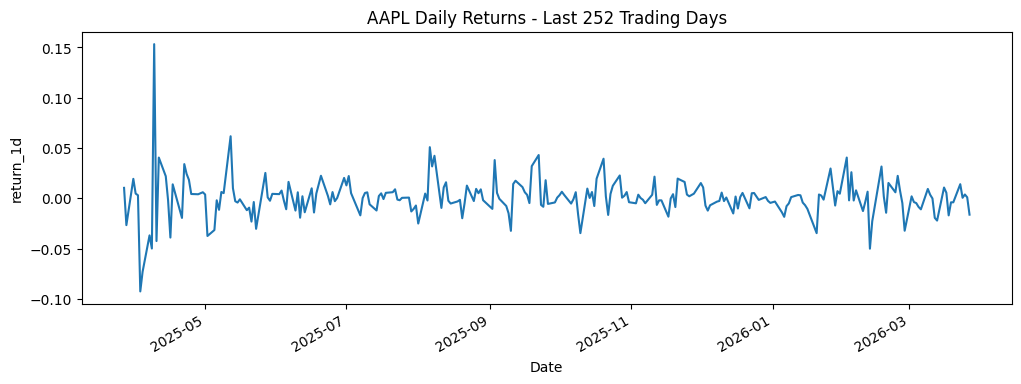

In [18]:
one.set_index('date')['return_1d'].tail(252).plot(figsize=(12, 4), title=f'{ticker} Daily Returns - Last 252 Trading Days')
plt.xlabel('Date')
plt.ylabel('return_1d')
plt.show()

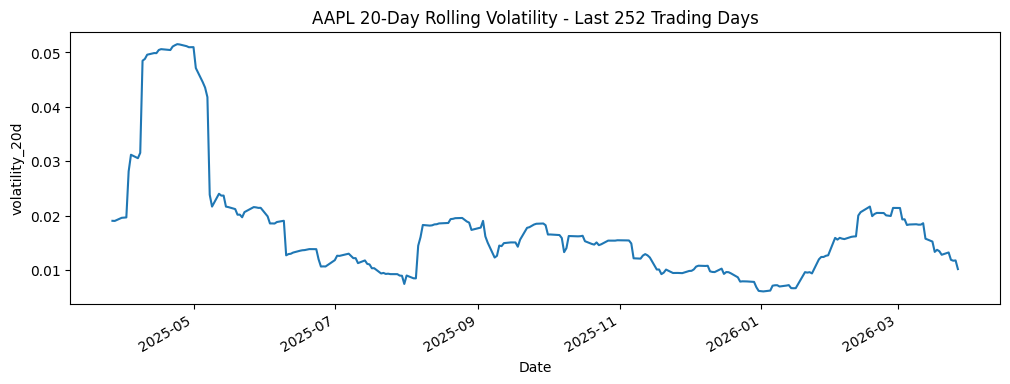

In [19]:
one.set_index('date')['volatility_20d'].tail(252).plot(figsize=(12, 4), title=f'{ticker} 20-Day Rolling Volatility - Last 252 Trading Days')
plt.xlabel('Date')
plt.ylabel('volatility_20d')
plt.show()

## Feature relationships with target

In [20]:
target_means = df.groupby('target_next_day_up')[feature_cols].mean().T
target_means

target_next_day_up,0,1
return_1d,1.553691e-03,3.927010e-04
return_5d,5.158847e-03,4.152241e-03
return_20d,1.894460e-02,1.821974e-02
sma_5,1.334679e+02,1.373854e+02
sma_20,1.328642e+02,1.368402e+02
sma_50,1.317420e+02,1.356056e+02
dist_from_sma_20,8.131952e-03,7.102461e-03
dist_from_sma_50,1.967445e-02,1.993473e-02
volatility_5d,1.602139e-02,1.538534e-02
volatility_20d,1.708325e-02,1.648761e-02


In [21]:
corr_cols = feature_cols + ['target_next_day_up']
corr = df[corr_cols].corr(numeric_only=True)
corr['target_next_day_up'].sort_values(ascending=False)

target_next_day_up    1.000000
sma_20                0.013130
sma_5                 0.012889
sma_50                0.012863
dist_from_sma_50      0.001686
volume_ratio_20d     -0.000673
return_20d           -0.004271
dist_from_sma_20     -0.011055
return_5d            -0.011820
volume_avg_20d       -0.018274
volatility_5d        -0.024788
volatility_20d       -0.026868
return_1d            -0.028984
Name: target_next_day_up, dtype: float64

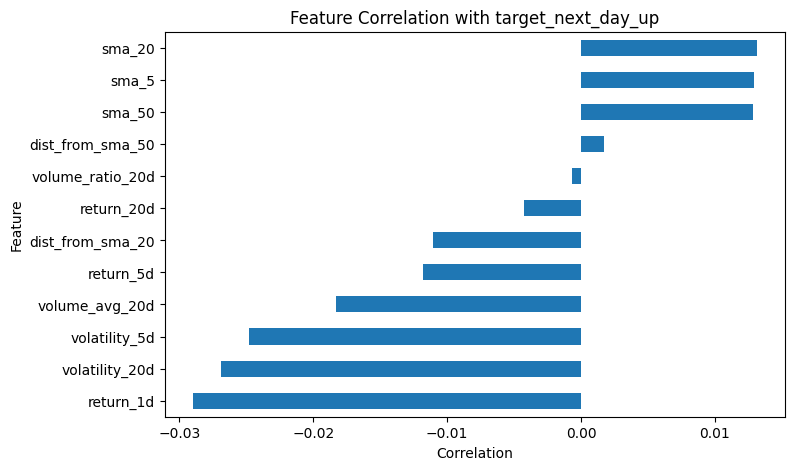

In [22]:
plt.figure(figsize=(8, 5))
corr['target_next_day_up'].drop('target_next_day_up').sort_values().plot(kind='barh')
plt.title('Feature Correlation with target_next_day_up')
plt.xlabel('Correlation')
plt.ylabel('Feature')
plt.show()

## Recent slice preview

In [23]:
recent = df.sort_values(['ticker', 'date']).groupby('ticker', group_keys=False).tail(5)
recent

,date,ticker,open,high,low,close,adjusted_close,volume,return_1d,return_5d,return_20d,sma_5,sma_20,sma_50,dist_from_sma_20,dist_from_sma_50,volatility_5d,volatility_20d,volume_avg_20d,volume_ratio_20d,target_next_day_up
4946,2026-03-23,AAPL,253.970000,254.600010,250.280000,251.490010,251.490010,40546100,0.014113,-0.005261,-0.055188,250.522006,259.253501,260.979000,-0.029946,-0.036359,0.011625,0.013215,41655310.0,0.973372,1
4947,2026-03-24,AAPL,250.350010,254.830000,249.550000,251.640000,251.640000,45152300,0.000596,-0.010188,-0.075329,250.004006,258.228501,260.824400,-0.025514,-0.035213,0.011123,0.011862,41562195.0,1.086379,1
4948,2026-03-25,AAPL,254.100010,255.000000,251.600010,252.620000,252.620000,28476700,0.003894,0.010723,-0.078802,250.540006,257.148001,260.671800,-0.017609,-0.030889,0.007450,0.011697,41300315.0,0.689503,1
4949,2026-03-26,AAPL,252.120000,257.000000,250.770000,252.890000,252.890000,41796700,0.001069,0.015786,-0.073493,251.326004,256.145000,260.508600,-0.012708,-0.029245,0.006732,0.011751,41772895.0,1.000570,0
4950,2026-03-27,AAPL,253.899990,255.490010,248.070007,248.800000,248.800000,47842500,-0.016173,0.003266,-0.058218,251.488002,255.376001,260.285400,-0.025750,-0.044126,0.010897,0.010155,40546695.0,1.179936,0
9897,2026-03-23,MSFT,383.899990,387.209990,381.679990,383.000000,383.000000,29680100,0.002959,-0.042380,-0.003823,389.018000,398.693998,418.870200,-0.039364,-0.085636,0.009924,0.013417,33494775.0,0.886111,0
9898,2026-03-24,MSFT,382.359990,382.470000,371.850010,372.739990,372.739990,42733600,-0.026789,-0.066774,-0.041800,383.683998,397.880998,416.739399,-0.063187,-0.105580,0.011658,0.014358,33937220.0,1.259196,0
9899,2026-03-25,MSFT,376.920010,377.059998,369.630000,371.040009,371.040009,31181200,-0.004561,-0.052962,-0.073789,379.533998,396.402998,414.616600,-0.063983,-0.105101,0.011782,0.012246,33315005.0,0.935951,0
9900,2026-03-26,MSFT,370.820010,374.720000,365.190000,365.970000,365.970000,36836600,-0.013664,-0.059251,-0.088992,374.924000,394.615498,412.522600,-0.072591,-0.112849,0.011632,0.012335,33436540.0,1.101687,0
9901,2026-03-27,MSFT,361.899990,362.450010,356.510010,356.769990,356.769990,37763600,-0.025139,-0.065729,-0.091587,369.903998,392.816998,410.470399,-0.091765,-0.130827,0.012873,0.012560,32756360.0,1.152863,0


## Suggested interpretation

If this notebook looks healthy, you should expect:
- zero duplicate `(date, ticker)` rows
- zero or near-zero nulls in the saved feature table
- target roughly balanced between 0 and 1
- rolling averages that visibly smooth price series
- volatility that rises during rough periods and falls during calmer periods
- mostly modest correlations with the target

That last point is important: if a feature shows an extremely strong correlation with the target, that can be a sign of leakage.

Once these checks look good, the next step is time-aware train/validation/test splitting and a first baseline model.